# YUPA INSURANCE

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

from datetime import datetime

In [25]:
df = pd.read_csv('claims_yupa.csv')

#display first few rows of the dataframe
df.head()

,Claim ID,Hospital Name,Patient ID,Procedure,Claim Amount,Date,Status
0,C001,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-10,Settled
1,C002,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-12,Settled
2,C003,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-15,Settled
3,C004,Metro Hosp.,P124,Appendectomy,"80,000",2025-01-11,Settled
4,C005,CityCare Hosp.,P125,Cataract Surgery,"40,000",2025-01-13,Settled


In [26]:
print(df.shape)

df.head()

df.info()

df.describe(include='all')

(100, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Claim ID       100 non-null    object
 1   Hospital Name  100 non-null    object
 2   Patient ID     100 non-null    object
 3   Procedure      100 non-null    object
 4   Claim Amount   100 non-null    object
 5   Date           100 non-null    object
 6   Status         100 non-null    object
dtypes: object(7)
memory usage: 5.6+ KB


,Claim ID,Hospital Name,Patient ID,Procedure,Claim Amount,Date,Status
count,100,100,100,100,100,100,100
unique,100,3,93,7,7,98,1
top,C001,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-20,Settled
freq,1,47,8,31,31,2,100


In [27]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter

In [28]:
# ==========================
# BASIC DATASET STATISTICS
# ==========================

print("=" * 50)
print("        YUPA INSURANCE DATASET SUMMARY")
print("=" * 50)

# Number of Claims
num_claims = len(df)

# Number of Hospitals
num_hospitals = df["Hospital Name"].nunique()

# Number of Patients
num_patients = df["Patient ID"].nunique()

# Number of Procedures
num_procedures = df["Procedure"].nunique()

# Total Claim Amount
total_claim = df["Claim Amount"].sum()

# Average Claim Amount
# convert Claim Amount to numeric (remove commas) and recompute totals/average
df["Claim Amount"] = pd.to_numeric(df["Claim Amount"].astype(str).str.replace(",", "", regex=False), errors="coerce")
total_claim = df["Claim Amount"].sum()
avg_claim = df["Claim Amount"].mean()

# Median Claim Amount
median_claim = df["Claim Amount"].median()

# Minimum Claim Amount
min_claim = df["Claim Amount"].min()

# Maximum Claim Amount
max_claim = df["Claim Amount"].max()

# Print Results
print(f"Total Claims           : {num_claims}")
print(f"Unique Hospitals       : {num_hospitals}")
print(f"Unique Patients        : {num_patients}")
print(f"Unique Procedures      : {num_procedures}")
print("-" * 50)
print(f"Total Claim Amount     : ₹{total_claim:,.2f}")
print(f"Average Claim Amount   : ₹{avg_claim:,.2f}")
print(f"Median Claim Amount    : ₹{median_claim:,.2f}")
print(f"Minimum Claim Amount   : ₹{min_claim:,.2f}")
print(f"Maximum Claim Amount   : ₹{max_claim:,.2f}")
print("=" * 50)

        YUPA INSURANCE DATASET SUMMARY
Total Claims           : 100
Unique Hospitals       : 3
Unique Patients        : 93
Unique Procedures      : 7
--------------------------------------------------
Total Claim Amount     : ₹9,515,000.00
Average Claim Amount   : ₹95,150.00
Median Claim Amount    : ₹80,000.00
Minimum Claim Amount   : ₹35,000.00
Maximum Claim Amount   : ₹200,000.00


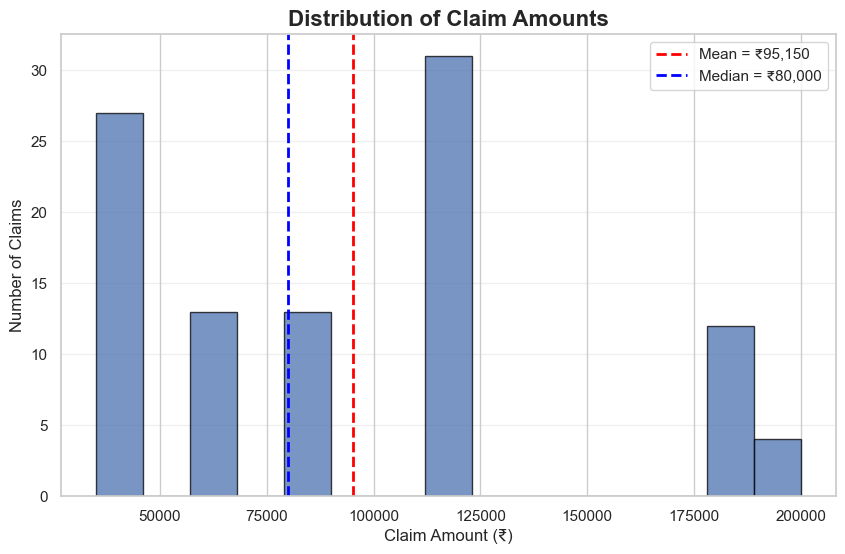

In [29]:
# Claim Amount Distribution with Mean & Median

mean_claim = pd.to_numeric(df["Claim Amount"].astype(str).str.replace(",", "", regex=False), errors="coerce").mean()
median_claim = pd.to_numeric(df["Claim Amount"].astype(str).str.replace(",", "", regex=False), errors="coerce").median()

plt.figure(figsize=(10,6))

plt.hist(
    df["Claim Amount"],
    bins=15,
    edgecolor='black',
    alpha=0.75
)

plt.axvline(mean_claim,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"Mean = ₹{mean_claim:,.0f}")

plt.axvline(median_claim,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f"Median = ₹{median_claim:,.0f}")

plt.title("Distribution of Claim Amounts", fontsize=16, fontweight='bold')
plt.xlabel("Claim Amount (₹)")
plt.ylabel("Number of Claims")

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

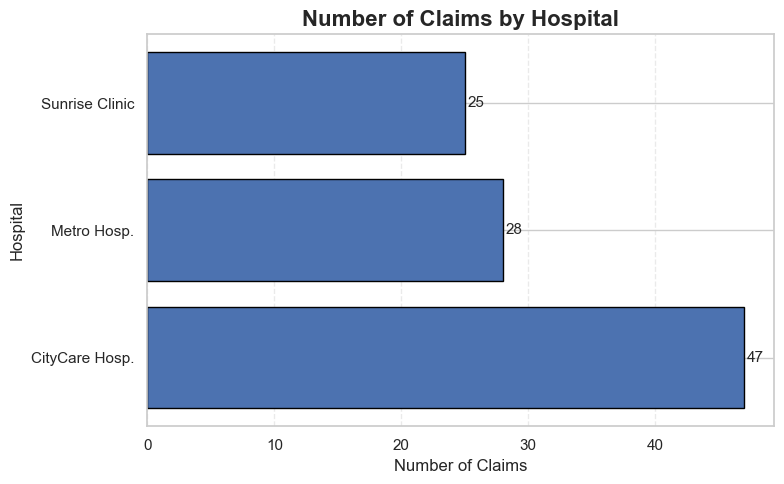

Claims by Hospital
-----------------------------------
Hospital Name
CityCare Hosp.    47
Metro Hosp.       28
Sunrise Clinic    25
Name: count, dtype: int64


In [30]:
# Number of Claims by Hospital

hospital_counts = df["Hospital Name"].value_counts()

plt.figure(figsize=(8,5))

plt.barh(
    hospital_counts.index,
    hospital_counts.values,
    edgecolor='black'
)

plt.title("Number of Claims by Hospital", fontsize=16, fontweight='bold')
plt.xlabel("Number of Claims", fontsize=12)
plt.ylabel("Hospital", fontsize=12)

# Add value labels
for i, value in enumerate(hospital_counts.values):
    plt.text(value + 0.2, i, str(value), va='center', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("Claims by Hospital")
print("-"*35)

hospital_counts = df["Hospital Name"].value_counts()

print(hospital_counts)

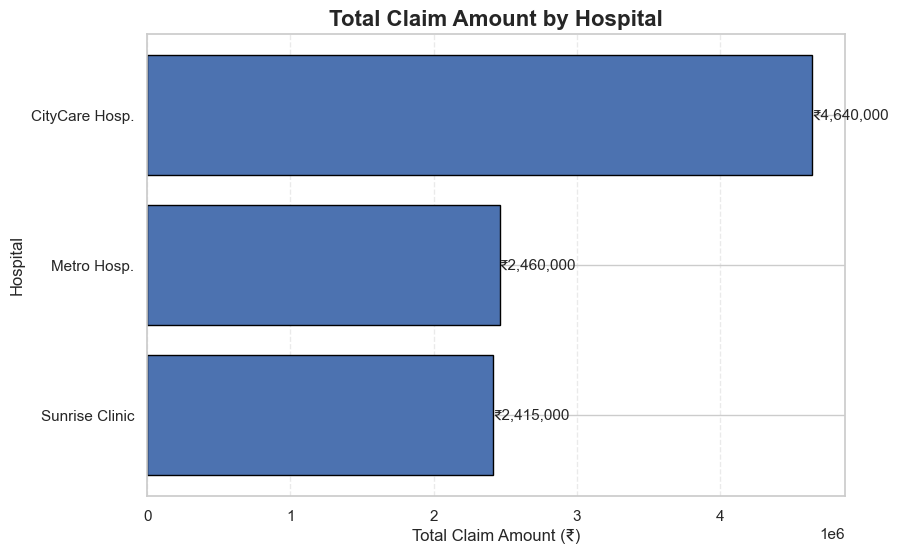

In [31]:
# ==========================================
# Total Claim Amount by Hospital
# ==========================================

# Group data by hospital and calculate total claim amount
hospital_claims = (
    df.groupby("Hospital Name")["Claim Amount"]
      .sum()
      .sort_values(ascending=True)
)

# Create figure
plt.figure(figsize=(9,6))

# Horizontal bar chart
bars = plt.barh(
    hospital_claims.index,
    hospital_claims.values,
    edgecolor='black'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2000,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va='center',
        fontsize=11
    )

# Labels and title
plt.title("Total Claim Amount by Hospital", fontsize=16, fontweight='bold')
plt.xlabel("Total Claim Amount (₹)", fontsize=12)
plt.ylabel("Hospital", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

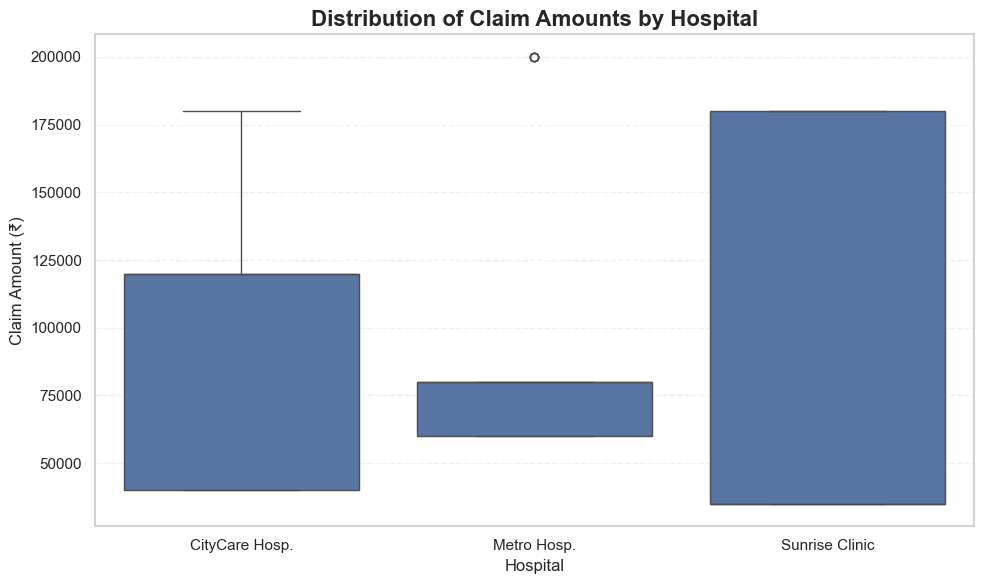

In [32]:
# Claim Amount Distribution by Hospital

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Hospital Name",
    y="Claim Amount"
)

plt.title("Distribution of Claim Amounts by Hospital", fontsize=16, fontweight='bold')
plt.xlabel("Hospital")
plt.ylabel("Claim Amount (₹)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

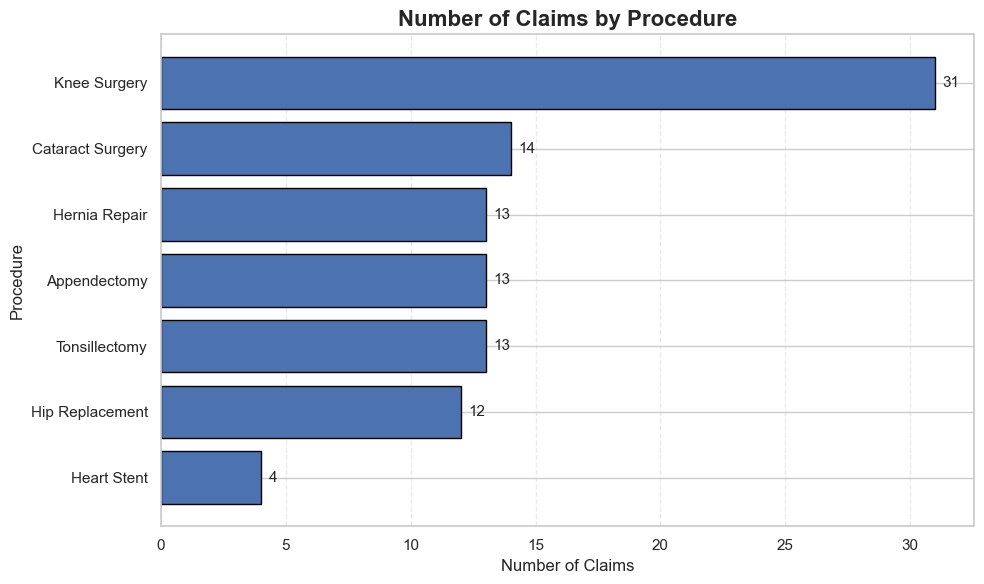

In [33]:
# Procedure Frequency

# Count each procedure
procedure_counts = (
    df["Procedure"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    procedure_counts.index,
    procedure_counts.values,
    edgecolor='black'
)

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va='center',
        fontsize=11
    )

plt.title("Number of Claims by Procedure", fontsize=16, fontweight='bold')
plt.xlabel("Number of Claims", fontsize=12)
plt.ylabel("Procedure", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

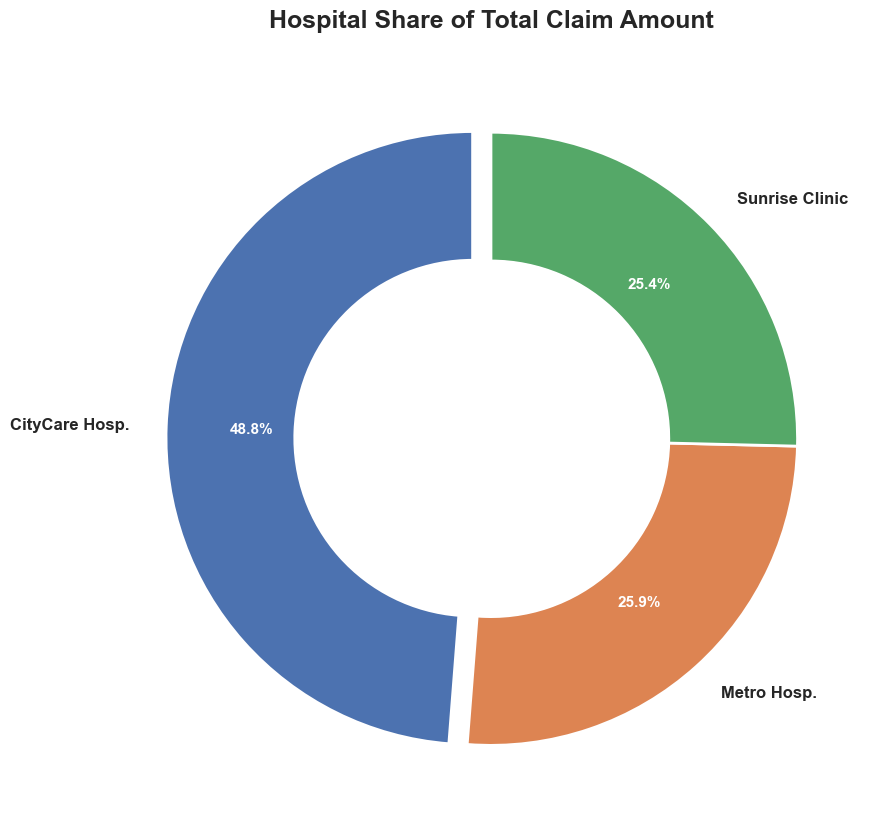

In [34]:
import matplotlib.pyplot as plt

# Total claim amount by hospital
hospital_claims = (
    df.groupby("Hospital Name")["Claim Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 9))

wedges, texts, autotexts = plt.pie(
    hospital_claims,
    labels=hospital_claims.index,
    
    startangle=90,
    explode=[0.06] + [0]*(len(hospital_claims)-1),
    autopct="%1.1f%%",
    pctdistance=0.72,      # Percentages inside
    labeldistance=1.12,    # Labels outside
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
)

# Beautify labels
plt.setp(texts,
         fontsize=12,
         fontweight="bold")

# Beautify percentages
plt.setp(autotexts,
         fontsize=11,
         fontweight="bold",
         color="white")

# White circle in center
centre_circle = plt.Circle((0, 0), 0.58, fc="white")
plt.gca().add_artist(centre_circle)

plt.title(
    "Hospital Share of Total Claim Amount",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

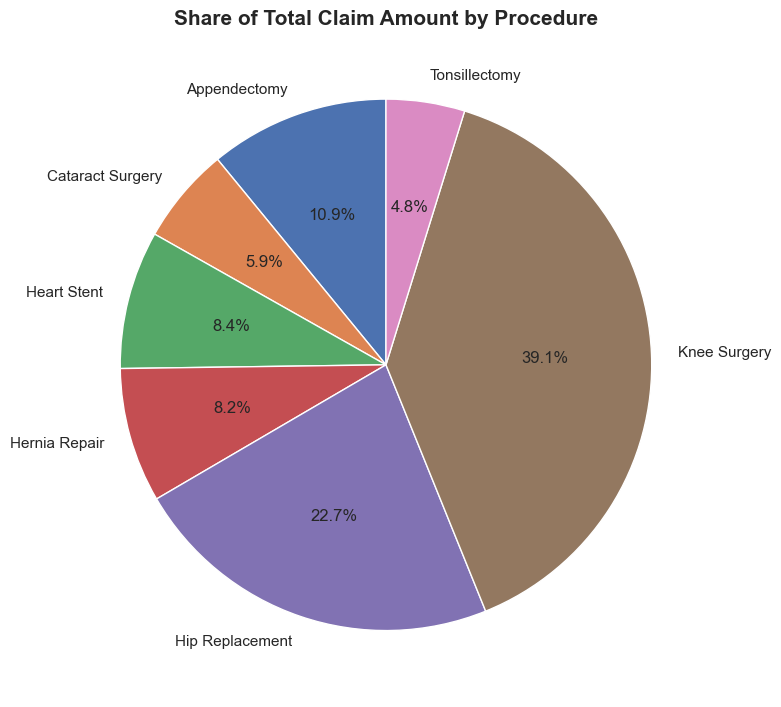

In [35]:
# ==========================================
# Share of Total Claim Amount by Procedure
# ==========================================

procedure_total = (
    df.groupby("Procedure")["Claim Amount"]
      .sum()
)

plt.figure(figsize=(8,8))

procedure_total = (
    df.groupby("Procedure")["Claim Amount"]
      .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    procedure_total,
    labels=procedure_total.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Share of Total Claim Amount by Procedure",
          fontsize=15,
          fontweight='bold')

plt.tight_layout()
plt.show()

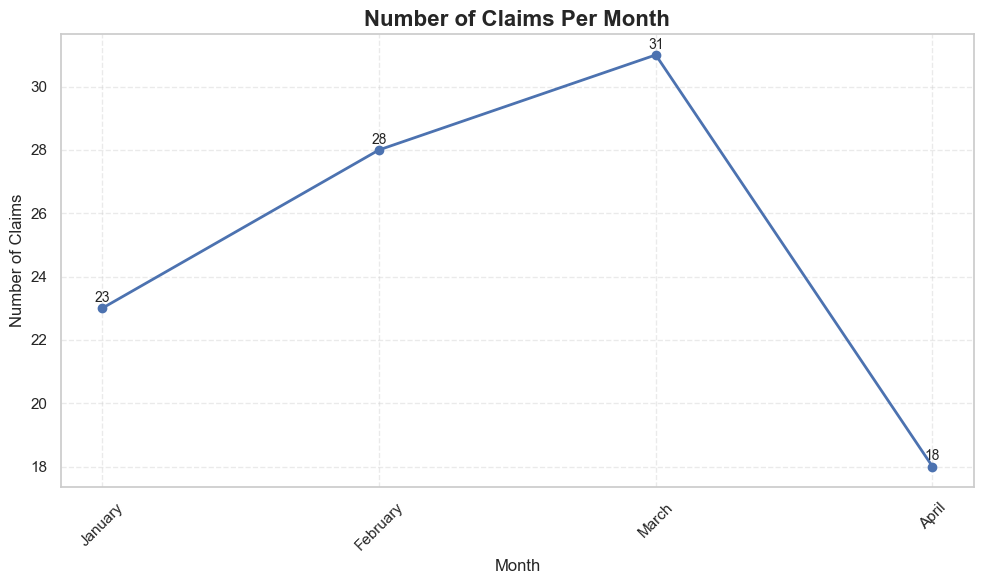

In [36]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

# Extract full month names
df["Month"] = df["Date"].dt.strftime("%B")

# Count number of claims per month
monthly_claims = (
    df.groupby("Month")
      .size()
      .reset_index(name="Number of Claims")
)

# Ensure months appear in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_claims["Month"] = pd.Categorical(
    monthly_claims["Month"],
    categories=month_order,
    ordered=True
)

monthly_claims = monthly_claims.sort_values("Month")

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    monthly_claims["Month"],
    monthly_claims["Number of Claims"],
    marker="o",
    linewidth=2
)

# Add data labels
for x, y in zip(monthly_claims["Month"], monthly_claims["Number of Claims"]):
    plt.text(x, y + 0.2, str(y), ha="center", fontsize=10)

plt.title("Number of Claims Per Month", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

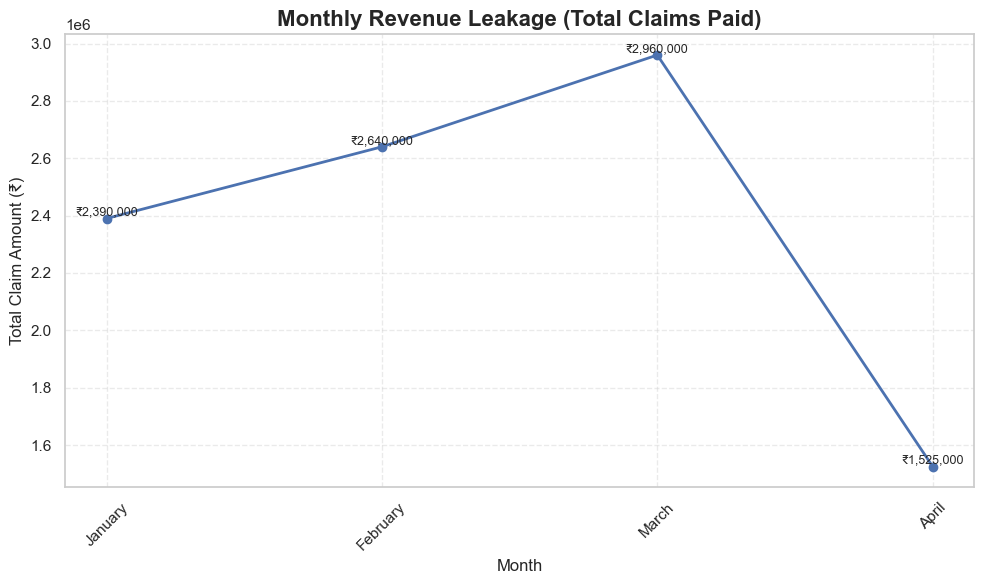

In [37]:
# Monthly Revenue Leakage (Total Claims Paid)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create month names
df["Month"] = df["Date"].dt.strftime("%B")

# Sum claim amount by month
monthly_leakage = (
    df.groupby("Month")["Claim Amount"]
      .sum()
      .reset_index()
)

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_leakage["Month"] = pd.Categorical(
    monthly_leakage["Month"],
    categories=month_order,
    ordered=True
)

monthly_leakage = monthly_leakage.sort_values("Month")

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    monthly_leakage["Month"],
    monthly_leakage["Claim Amount"],
    marker="o",
    linewidth=2
)

# Add value labels
for x, y in zip(monthly_leakage["Month"], monthly_leakage["Claim Amount"]):
    plt.text(x, y, f"₹{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.title("Monthly Revenue Leakage (Total Claims Paid)", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount (₹)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

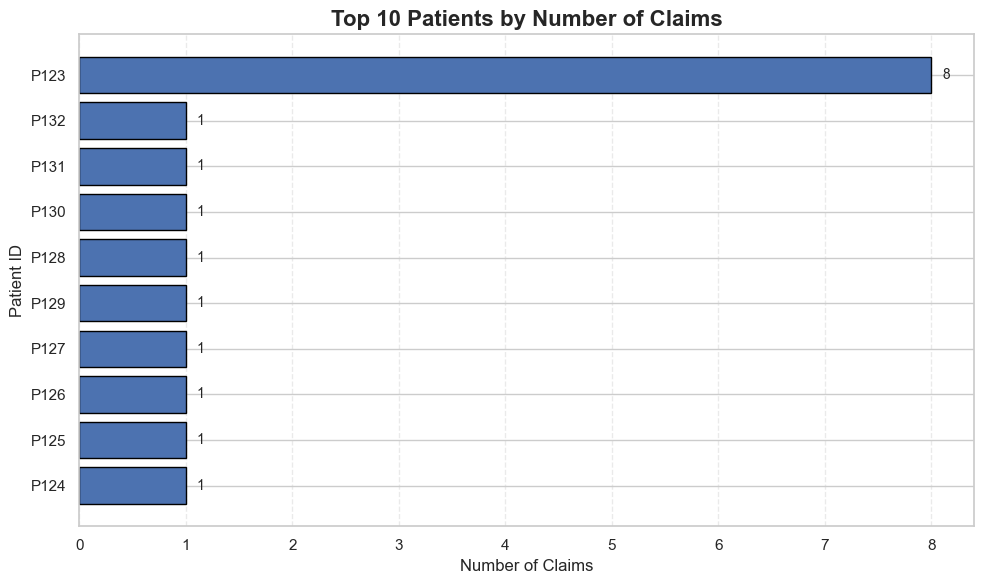

In [38]:
#Top 10 Patients by Number of Claims

# Count number of claims per patient
patient_claims = (
    df["Patient ID"]
      .value_counts()
      .head(10)
      .sort_values()
)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    patient_claims.index,
    patient_claims.values,
    edgecolor="black"
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va="center",
        fontsize=10
    )

plt.title("Top 10 Patients by Number of Claims", fontsize=16, fontweight="bold")
plt.xlabel("Number of Claims")
plt.ylabel("Patient ID")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

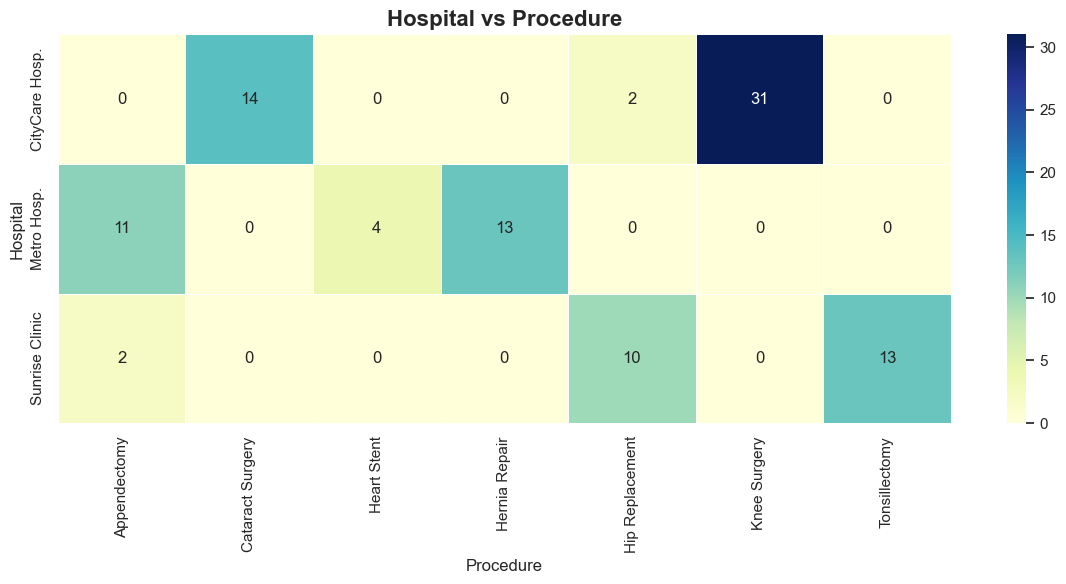

In [39]:
# Hospital vs Procedure Heatmap=

import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table
hospital_procedure = pd.crosstab(
    df["Hospital Name"],
    df["Procedure"]
)

# Plot heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    hospital_procedure,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Hospital vs Procedure", fontsize=16, fontweight="bold")
plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

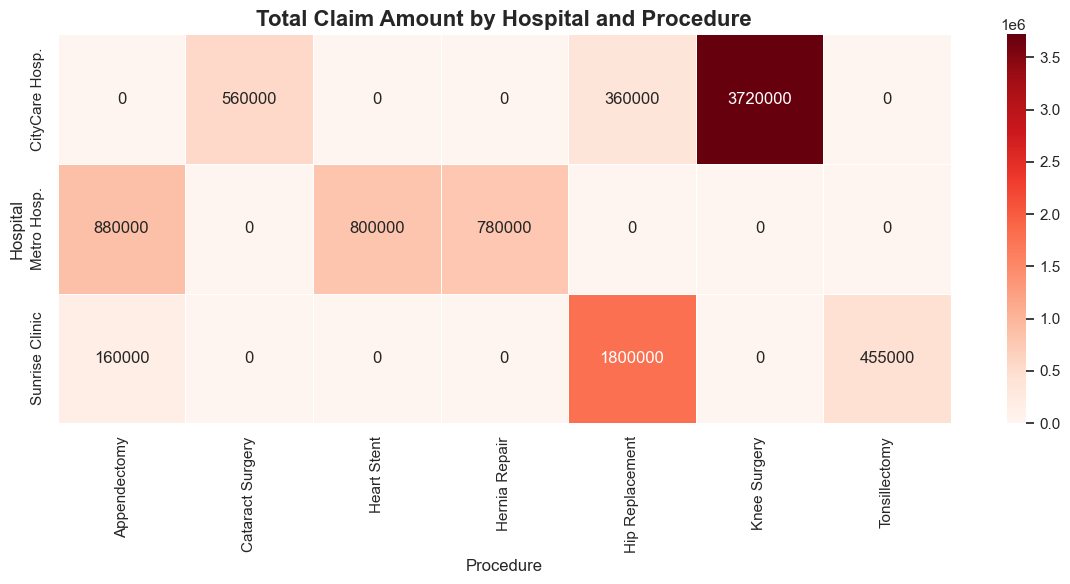

In [40]:
# Hospital vs Procedure (Total Claim Amount)

hospital_procedure_cost = pd.pivot_table(
    df,
    values="Claim Amount",
    index="Hospital Name",
    columns="Procedure",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    hospital_procedure_cost,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Total Claim Amount by Hospital and Procedure",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

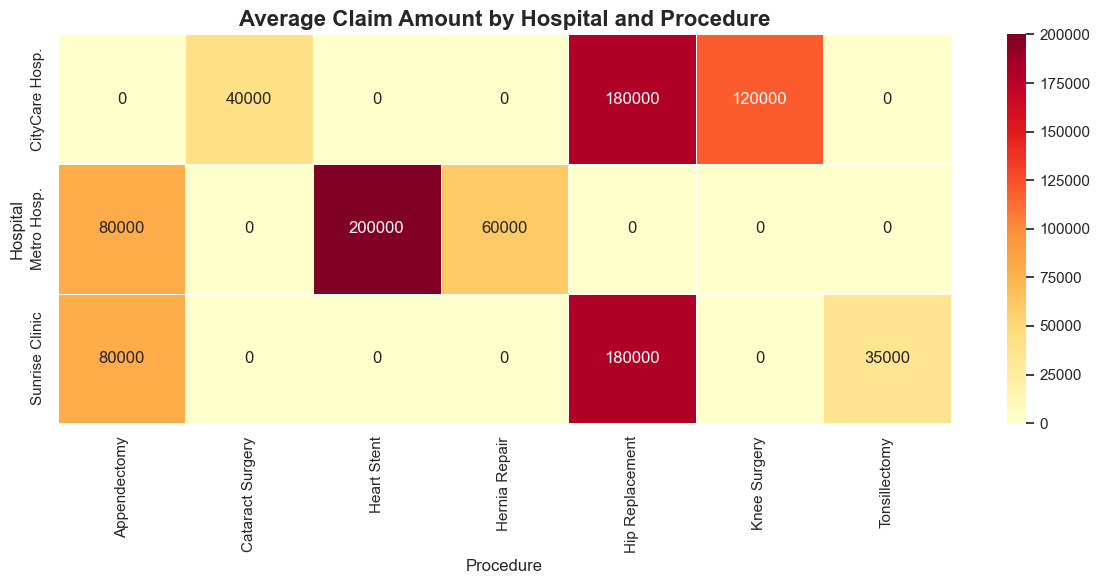

In [41]:
# Create pivot table

heatmap_data = pd.pivot_table(
    df,
    values="Claim Amount", 
    index="Hospital Name",
    columns="Procedure",
    aggfunc="mean",
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Average Claim Amount by Hospital and Procedure",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

In [42]:
# Display all claims for Patient P123

p123_claims = df[df["Patient ID"] == "P123"]

print("Potential Duplicate Claims for Patient P123")
print("-" * 45)
print(f"Total Claims: {len(p123_claims)}\n")

print(
    p123_claims[
        ["Claim ID", "Hospital Name", "Procedure", "Claim Amount", "Date"]
    ].to_string(index=False)
)

Potential Duplicate Claims for Patient P123
---------------------------------------------
Total Claims: 8

Claim ID  Hospital Name    Procedure  Claim Amount       Date
    C001 CityCare Hosp. Knee Surgery        120000 2025-01-10
    C002 CityCare Hosp. Knee Surgery        120000 2025-01-12
    C003 CityCare Hosp. Knee Surgery        120000 2025-01-15
    C006 CityCare Hosp. Knee Surgery        120000 2025-01-18
    C022 CityCare Hosp. Knee Surgery        120000 2025-01-29
    C023 CityCare Hosp. Knee Surgery        120000 2025-01-30
    C024 CityCare Hosp. Knee Surgery        120000 2025-02-01
    C100 CityCare Hosp. Knee Surgery        120000 2025-04-18


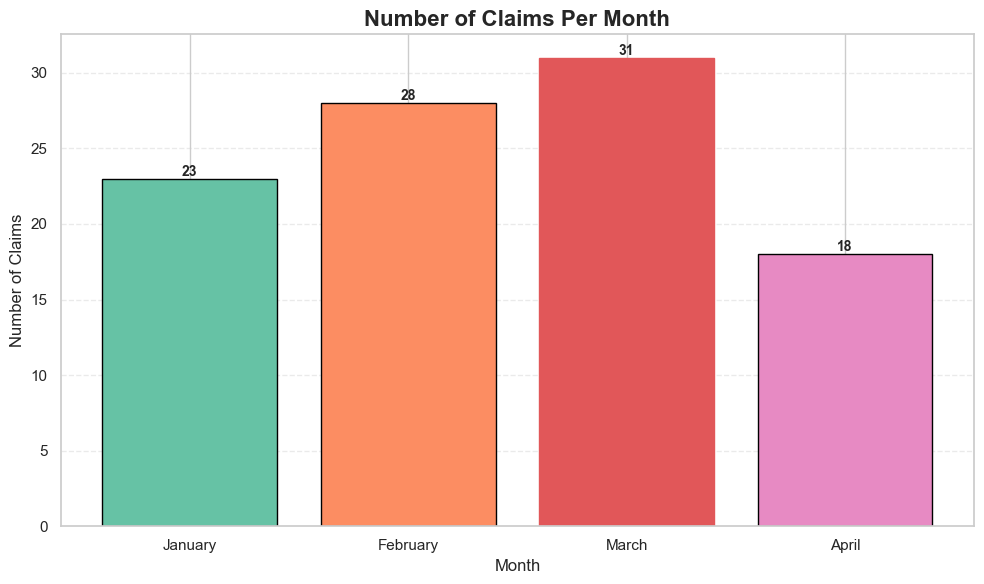

In [43]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract month name
df["Month"] = df["Date"].dt.month_name()

# Keep months in calendar order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

# Count claims per month
monthly_claims = (
    df.groupby("Month", observed=True)
      .size()
      .reset_index(name="Number of Claims")
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    monthly_claims["Month"],
    monthly_claims["Number of Claims"],
    color=plt.cm.Set2(range(len(monthly_claims))),
    edgecolor="black"
)

# Highlight month with highest claims
bars[monthly_claims["Number of Claims"].idxmax()].set_color("#E15759")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Number of Claims Per Month", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Claims")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

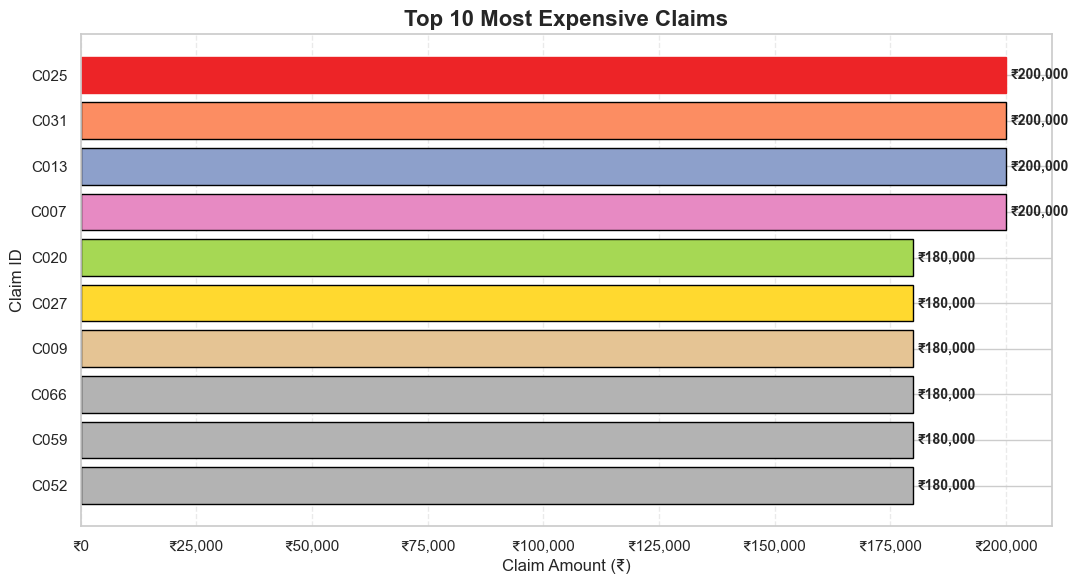

In [45]:
from matplotlib.ticker import StrMethodFormatter

# Top 10 most expensive claims
top_claims = (
    df.sort_values(by="Claim Amount", ascending=False)
      .head(10)
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_claims["Claim ID"],
    top_claims["Claim Amount"],
    color=plt.cm.Set2(range(len(top_claims))),
    edgecolor="black"
)

# Highest claim highlighted
bars[0].set_color("#ED2427")

# Value labels
for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"₹{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
        
    )

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Most Expensive Claims",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Claim Amount (₹)")
plt.ylabel("Claim ID")

# Remove scientific notation
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

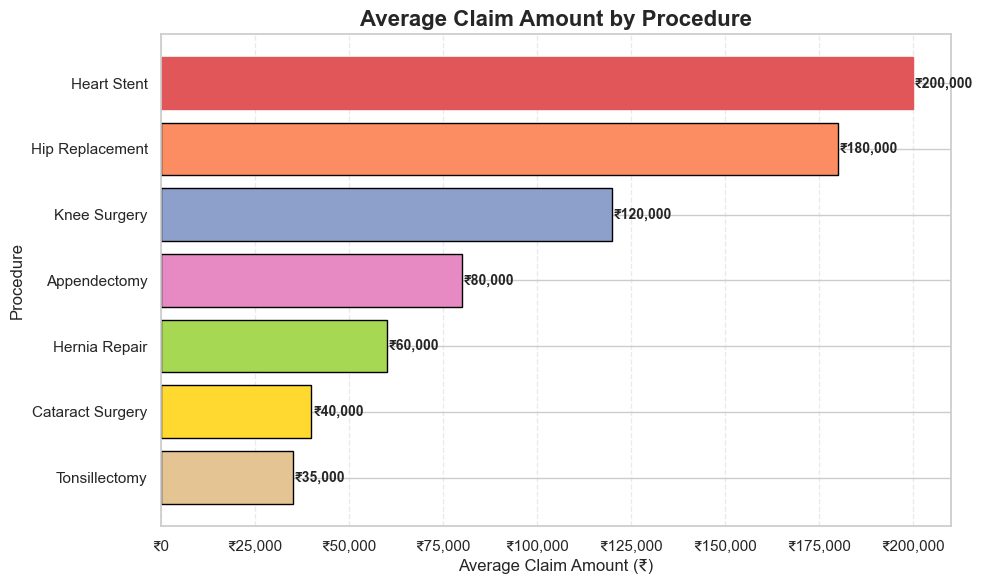

In [46]:
# Average Claim Amount per Procedure
avg_claim_procedure = (
    df.groupby("Procedure")["Claim Amount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    avg_claim_procedure.index,
    avg_claim_procedure.values,
    color=plt.cm.Set2(range(len(avg_claim_procedure))),
    edgecolor="black"
)

# Highlight the highest average claim
bars[0].set_color("#E15759")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height()/2,
        f"₹{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))

plt.title("Average Claim Amount by Procedure", fontsize=16, fontweight="bold")
plt.xlabel("Average Claim Amount (₹)")
plt.ylabel("Procedure")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [47]:
claim_frequency = len(df) / df["Patient ID"].nunique()

print(f"Average Number of Claims per Patient: {claim_frequency:.2f}")

Average Number of Claims per Patient: 1.08
